In [1]:
# ============================================
# IMPORT REQUIRED LIBRARIES
# ============================================

import torch

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
# ============================================
# SET DEVICE FOR TRAINING
# ============================================

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)

print("Using Device:", device)

Using Device: cuda


In [3]:
# ============================================
# DATASET PATHS
# ============================================

train_dir = "../dataset/train"

val_dir = "../dataset/val"

test_dir = "../dataset/test"

In [4]:
# ============================================
# IMAGE TRANSFORMS
# ============================================

train_transforms = transforms.Compose([

    # Resize images
    transforms.Resize((224, 224)),

    # Data augmentation
    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet stats
    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

# ============================================
# VALIDATION / TEST TRANSFORMS
# ============================================

val_test_transforms = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
# ============================================
# LOAD DATASETS
# ============================================

train_dataset = datasets.ImageFolder(

    root=train_dir,

    transform=train_transforms
)

val_dataset = datasets.ImageFolder(

    root=val_dir,

    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(

    root=test_dir,

    transform=val_test_transforms
)

print("Train Dataset Size:", len(train_dataset))

print("Validation Dataset Size:", len(val_dataset))

print("Test Dataset Size:", len(test_dataset))

Train Dataset Size: 1050
Validation Dataset Size: 225
Test Dataset Size: 225


In [6]:
# ============================================
# CREATE DATALOADERS
# ============================================

BATCH_SIZE = 32

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=4,

    pin_memory=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=4,

    pin_memory=True
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=4,

    pin_memory=True
)

print("DataLoaders Created Successfully!")

DataLoaders Created Successfully!


In [7]:
# ============================================
# TEST DATALOADER BATCH
# ============================================

images, labels = next(iter(train_loader))

print("Image Batch Shape:", images.shape)

print("Label Batch Shape:", labels.shape)

Image Batch Shape: torch.Size([32, 3, 224, 224])
Label Batch Shape: torch.Size([32])


In [8]:
# ============================================
# MOVE BATCH TO GPU
# ============================================

images = images.to(device)

labels = labels.to(device)

print("Images Device:", images.device)

print("Labels Device:", labels.device)

Images Device: cuda:0
Labels Device: cuda:0


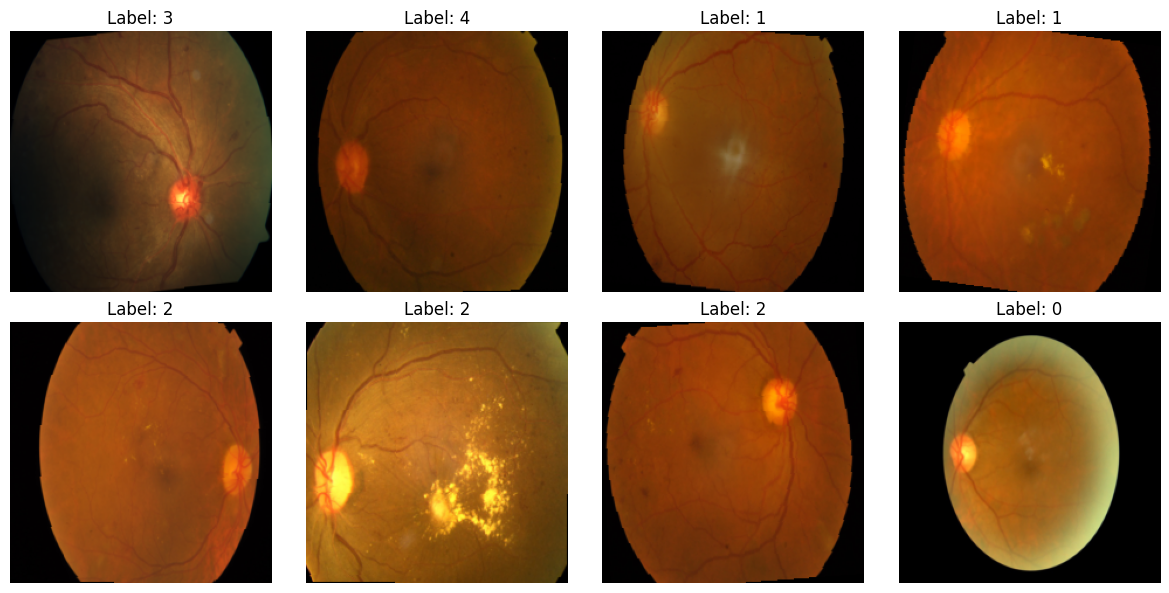

In [9]:
# ============================================
# DISPLAY TRANSFORMED IMAGES
# ============================================

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6)
)

for i, ax in enumerate(axes.flat):

    image = images[i].cpu()

    # Undo normalization
    image = image.permute(1, 2, 0)

    image = image * torch.tensor(
        [0.229, 0.224, 0.225]
    ) + torch.tensor(
        [0.485, 0.456, 0.406]
    )

    image = image.clamp(0, 1)

    ax.imshow(image)

    ax.set_title(
        f"Label: {labels[i].item()}"
    )

    ax.axis("off")

plt.tight_layout()

plt.show()